In [1]:
import randompack
import sys
sys.path.insert(0, "/Users/jonasson/dropbox/varmapack/release/python")
import varmapack
from statsmodels.tsa.statespace.varmax import VARMAX
print(varmapack.__file__)
print(hasattr(varmapack.Model, "acvf"))

/Users/jonasson/dropbox/varmapack/release/python/varmapack/__init__.py
True


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

case = varmapack.testcase("rho", p=3, q=3, r=2, rho=0.98)
p, q = case.order
r = case.dimension
length = 100
nrep = 1

print("order:", case.order)
print("dimension:", r)
print("A shape:", case.A.shape)
print("B shape:", case.B.shape)
print("Sig shape:", case.Sig.shape)


order: (3, 3)
dimension: 2
A shape: (2, 2, 3)
B shape: (2, 2, 3)
Sig shape: (2, 2)


In [3]:
def varmax_params(model):
    p, q = model.order
    r = model.dimension
    parts = []
    if p > 0:
        ar = np.concatenate([model.A[lag] for lag in range(p)], axis=1)
        parts.append(ar.reshape(-1))
    if q > 0:
        ma = np.concatenate([model.B[lag] for lag in range(q)], axis=1)
        parts.append(ma.reshape(-1))
    L = np.linalg.cholesky(model.Sig)
    parts.append(L[np.tril_indices(r)])
    return np.concatenate(parts)

def make_varmax(model):
    p, q = model.order
    r = model.dimension
    dummy = np.zeros((max(p + q + 10, 20), r))
    return VARMAX(
        dummy,
        order=(p, q),
        trend="n",
        error_cov_type="unstructured",
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

varmax = make_varmax(case)
params = varmax_params(case)
print("parameter count:", len(params))
print("expected count:", len(varmax.param_names))
assert len(params) == len(varmax.param_names)


parameter count: 27
expected count: 27


Varmapack shape: (1, 100, 2)
finite: True


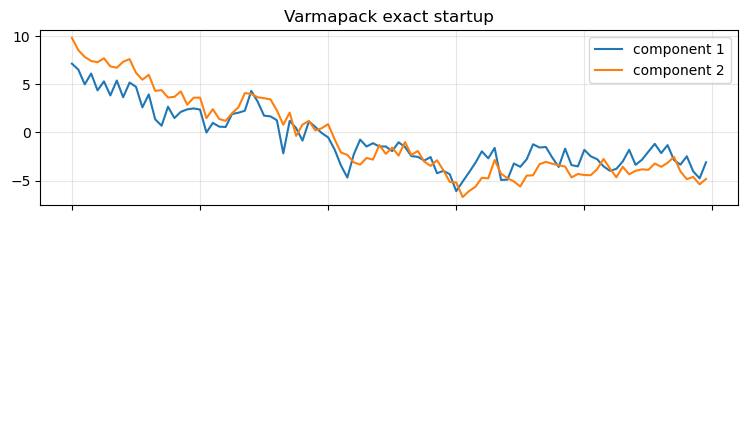

In [4]:
rng = randompack.Rng()
rng.seed(123)
X_vp = case.sim(length, nrep=nrep, rng=rng)

print("Varmapack shape:", X_vp.shape)
print("finite:", np.isfinite(X_vp).all())

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
ax[0].plot(X_vp[0, :, 0], label="component 1")
ax[0].plot(X_vp[0, :, 1], label="component 2")
ax[0].set_title("Varmapack exact startup")
ax[0].legend()
ax[0].grid(True, alpha=0.3)
ax[1].axis("off")
plt.show()


VARMAX shape: (100, 2, 1)
finite: True


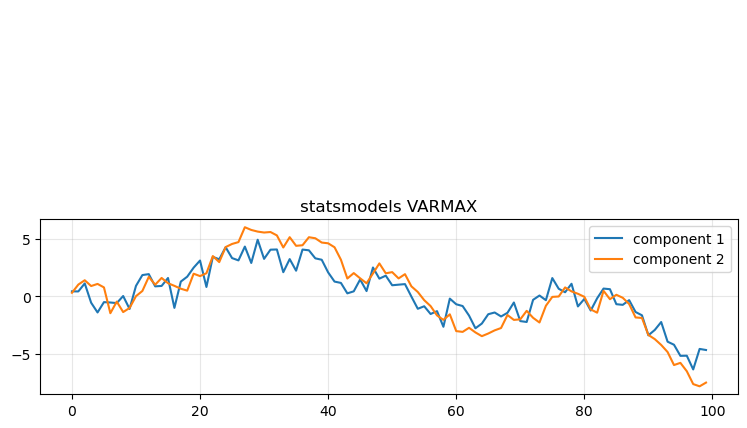

In [5]:
X_sm = varmax.simulate(
    params,
    nsimulations=length,
    repetitions=nrep,
    transformed=True,
)
X_sm_plot = X_sm[:, :, 0]

print("VARMAX shape:", X_sm.shape)
print("finite:", np.isfinite(X_sm).all())

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
ax[0].axis("off")
ax[1].plot(X_sm_plot[:, 0], label="component 1")
ax[1].plot(X_sm_plot[:, 1], label="component 2")
ax[1].set_title("statsmodels VARMAX")
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.show()


In [ ]:
n = 100
M = 10000
maxlag = 5

rng.seed(123)
X_vp_many = case.sim(n, nrep=M, rng=rng)
X_sm_many = varmax.simulate(
    params,
    nsimulations=n,
    repetitions=M,
    transformed=True,
)
X_sm_many = np.moveaxis(np.asarray(X_sm_many), 2, 0)

def pooled_autocov(paths, maxlag):
    mean = paths.reshape(-1, paths.shape[2]).mean(axis=0)
    Xc = paths - mean
    out = np.empty((maxlag + 1, paths.shape[2], paths.shape[2]))
    for lag in range(maxlag + 1):
        left = Xc[:, :paths.shape[1] - lag, :].reshape(-1, paths.shape[2])
        right = Xc[:, lag:, :].reshape(-1, paths.shape[2])
        out[lag] = left.T @ right / left.shape[0]
    return out

acvf = case.acvf(maxlag)
autocov_vp = pooled_autocov(X_vp_many, maxlag)
autocov_sm = pooled_autocov(X_sm_many, maxlag)

print("Varmapack paths:", X_vp_many.shape)
print("VARMAX paths:", X_sm_many.shape)
for lag in range(maxlag + 1):
    print("lag", lag)
    print("theoretical ACVF")
    print(acvf[lag])
    print("Varmapack pooled autocov")
    print(autocov_vp[lag])
    print("VARMAX pooled autocov")
    print(autocov_sm[lag])
    print("Varmapack - theoretical")
    print(autocov_vp[lag] - acvf[lag])
    print("VARMAX - theoretical")
    print(autocov_sm[lag] - acvf[lag])


In [7]:
n_start = 10
n_paths = 10000

X_start = varmax.simulate(
    params,
    nsimulations=n_start,
    repetitions=n_paths,
    transformed=True,
)
X_start = np.moveaxis(np.asarray(X_start), 2, 0)

print("VARMAX startup simulation shape:", X_start.shape)
print("Theoretical stationary lag 0 covariance:")
print(case.acvf(0)[0])
print("Covariance across repetitions at each time:")
for t in range(n_start):
    print("t =", t + 1)
    print(np.cov(X_start[:, t, :], rowvar=False))


VARMAX startup simulation shape: (10000, 10, 2)
Theoretical stationary lag 0 covariance:
[[18.11387472 24.92694691]
 [24.92694691 36.077608  ]]
Covariance across repetitions at each time:
t = 1
[[18.07353953 24.79149109]
 [24.79149109 35.79382769]]
t = 2
[[18.02947181 24.82433605]
 [24.82433605 35.9285647 ]]
t = 3
[[18.07123208 24.80660249]
 [24.80660249 35.81387886]]
t = 4
[[18.04780055 24.84953256]
 [24.84953256 35.96643647]]
t = 5
[[18.21449235 24.99396656]
 [24.99396656 36.03360835]]
t = 6
[[18.14140645 24.94420376]
 [24.94420376 36.03356864]]
t = 7
[[18.23825537 25.06338065]
 [25.06338065 36.23066782]]
t = 8
[[18.12607878 25.00459562]
 [25.00459562 36.25424076]]
t = 9
[[18.03363193 24.88295661]
 [24.88295661 36.10004814]]
t = 10
[[18.11162838 24.93617382]
 [24.93617382 36.10414714]]


In [ ]:
import time

bench_length = 100
bench_nrep = 10000
bench_values = bench_length*bench_nrep*r

rng.seed(123)
t0 = time.perf_counter()
X_vp_bench = case.sim(bench_length, nrep=bench_nrep, rng=rng)
t_vp = time.perf_counter() - t0

t0 = time.perf_counter()
X_sm_bench = varmax.simulate(
    params,
    nsimulations=bench_length,
    repetitions=bench_nrep,
    transformed=True,
)
t_sm = time.perf_counter() - t0

print("length:", bench_length)
print("replicates:", bench_nrep)
print("values:", bench_values)
print("Varmapack shape:", X_vp_bench.shape)
print("VARMAX shape:", X_sm_bench.shape)
print(f"Varmapack: {t_vp:.6f} s, {1e9*t_vp/bench_values:.1f} ns/value")
print(f"VARMAX:    {t_sm:.6f} s, {1e9*t_sm/bench_values:.1f} ns/value")
print(f"ratio VARMAX/Varmapack: {t_sm/t_vp:.2f}")


In [ ]:
case10 = varmapack.testcase("rho", p=3, q=3, r=10, rho=0.98)
varmax10 = make_varmax(case10)
params10 = varmax_params(case10)

bench_length = 100
bench_nrep = 1000
bench_r = case10.dimension
bench_values = bench_length*bench_nrep*bench_r

rng.seed(123)
t0 = time.perf_counter()
X_vp_bench10 = case10.sim(bench_length, nrep=bench_nrep, rng=rng)
t_vp10 = time.perf_counter() - t0

t0 = time.perf_counter()
X_sm_bench10 = varmax10.simulate(
    params10,
    nsimulations=bench_length,
    repetitions=bench_nrep,
    transformed=True,
)
t_sm10 = time.perf_counter() - t0

print("r:", bench_r)
print("length:", bench_length)
print("replicates:", bench_nrep)
print("values:", bench_values)
print("Varmapack shape:", X_vp_bench10.shape)
print("VARMAX shape:", X_sm_bench10.shape)
print(f"Varmapack: {t_vp10:.6f} s, {1e9*t_vp10/bench_values:.1f} ns/value")
print(f"VARMAX:    {t_sm10:.6f} s, {1e9*t_sm10/bench_values:.1f} ns/value")
print(f"ratio VARMAX/Varmapack: {t_sm10/t_vp10:.2f}")
